In [ ]:
1 Introduction
2 Dataset Description
3 Data Cleaning
4 Exploratory Data Analysis
5 Feature Engineering
6 Handling Class Imbalance (SMOTE)
7 Feature Scaling
8 Model Training
9 Model Comparison
10 Hyperparameter Tuning
11 Model Evaluation
12 Feature Importance
13 ROC Curve
14 SHAP Explainability
15 Model Saving

In [5]:
##imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
#dataset
df = pd.read_csv("../data/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
#check for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
#droping irrelevant columns
df = df.drop(["RowNumber","CustomerId","Surname"], axis=1)

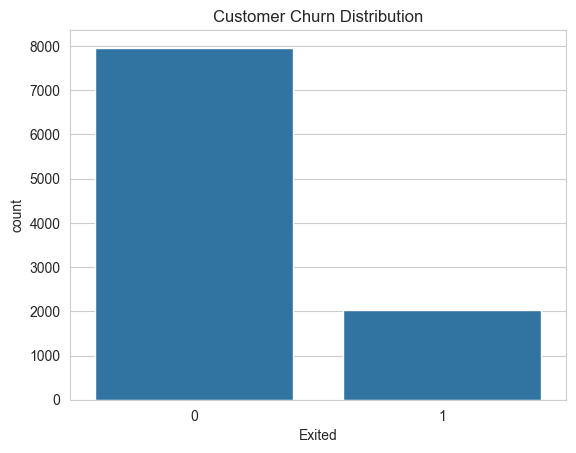

In [11]:
# churn distribution/ imbalance
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

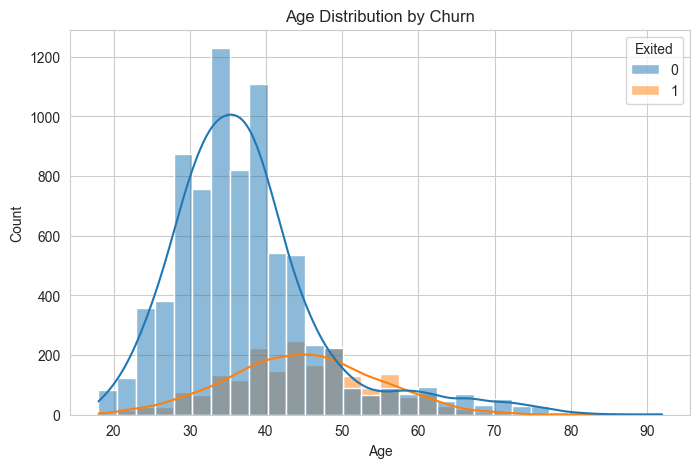

In [12]:
#age vs churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Exited", bins=30, kde=True)
plt.title("Age Distribution by Churn")
plt.show()

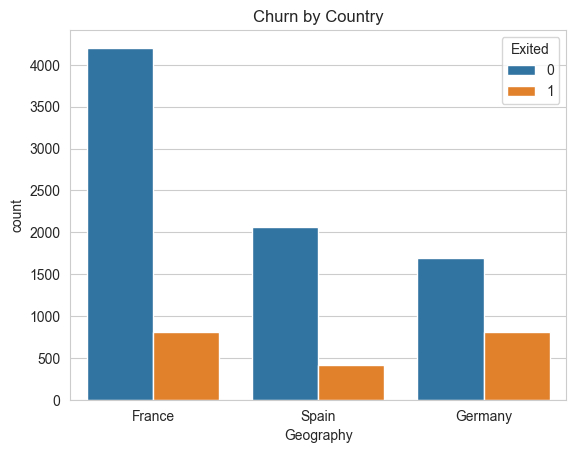

In [13]:
#geography vs churn
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Country")
plt.show()

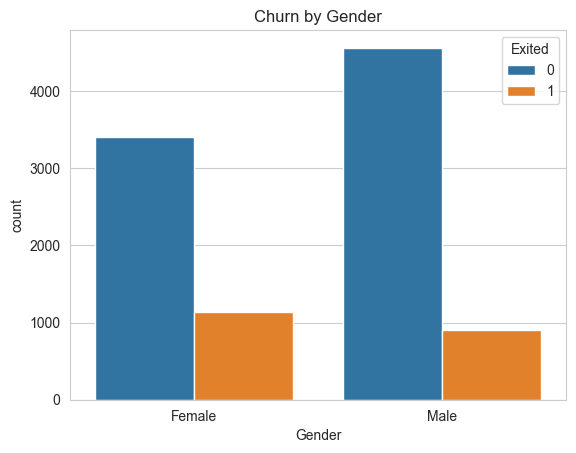

In [14]:
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Churn by Gender")
plt.show()


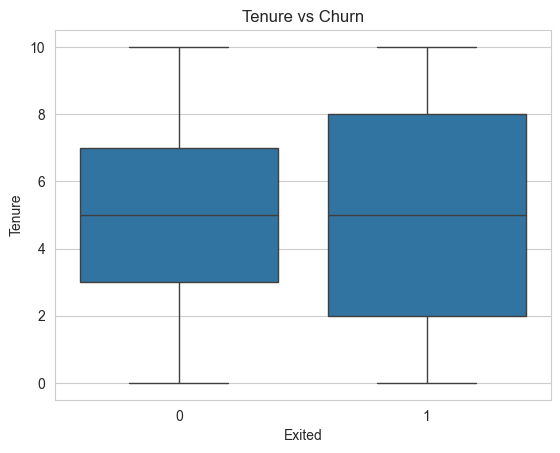

In [15]:
sns.boxplot(x="Exited", y="Tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [16]:
### converting categorical variable
df = pd.get_dummies(df, columns=["Geography","Gender"], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [17]:
#### spliting data 
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [20]:
## applying SMOTE(synthetic minority over sampling technique) because of imbalance data
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train,y_train)

In [21]:
y_train.value_counts()

Exited
0    6356
1    6356
Name: count, dtype: int64

In [22]:
## scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#---------Model training---------------


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [26]:
# model 1 Logistic regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


In [27]:
# model 2 Random forest 
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [28]:
#model 3 gradient boosting
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [30]:
#model 4 XGboost 
xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [31]:
### model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
def evaluate_model(y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1

In [33]:
evaluate_model(y_test, lr_pred)

evaluate_model(y_test, rf_pred)

evaluate_model(y_test, gb_pred)

evaluate_model(y_test, xgb_pred)

(0.8275, 0.5538116591928252, 0.628498727735369, 0.5887961859356377)

In [34]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7400,0.389565,0.569975,0.462810
1,Random Forest,0.8395,0.582949,0.643766,0.611850
2,Gradient Boosting,0.8195,0.531373,0.689567,0.600221
3,XGBoost,0.8275,0.553812,0.628499,0.588796


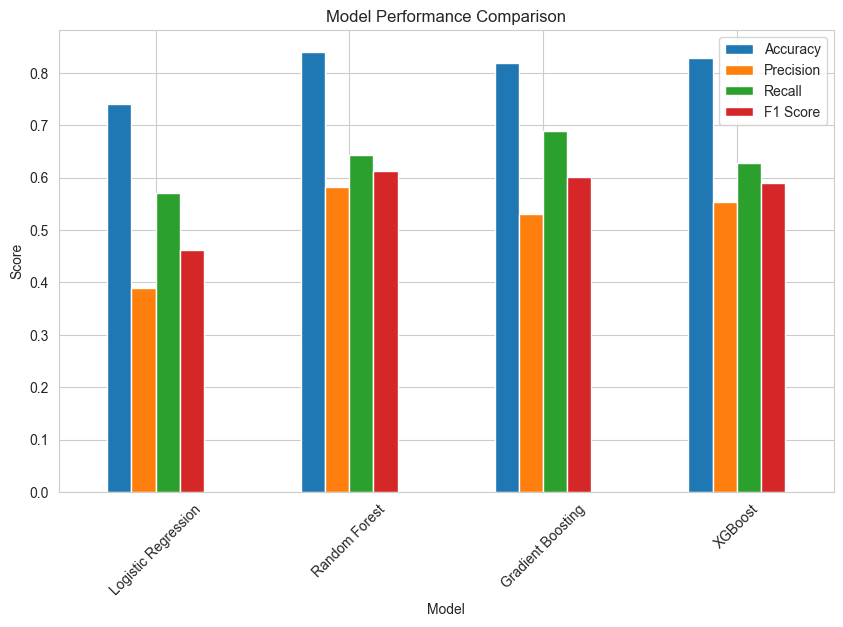

In [35]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

In [36]:
## choosing Random forest 


In [37]:
#hyperparameter tuning 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [38]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [39]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [40]:
grid.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [41]:
best_rf = grid.best_estimator_

In [42]:
best_pred = best_rf.predict(X_test)

evaluate_model(y_test, best_pred)

(0.835, 0.5727482678983834, 0.6310432569974554, 0.6004842615012107)

In [43]:
results.loc[len(results)] = [
    "Random Forest (Tuned)",
    accuracy_score(y_test, best_pred),
    precision_score(y_test, best_pred),
    recall_score(y_test, best_pred),
    f1_score(y_test, best_pred)
]

In [44]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7400,0.389565,0.569975,0.462810
1,Random Forest,0.8395,0.582949,0.643766,0.611850
2,Gradient Boosting,0.8195,0.531373,0.689567,0.600221
3,XGBoost,0.8275,0.553812,0.628499,0.588796
4,Random Forest (Tuned),0.8350,0.572748,0.631043,0.600484


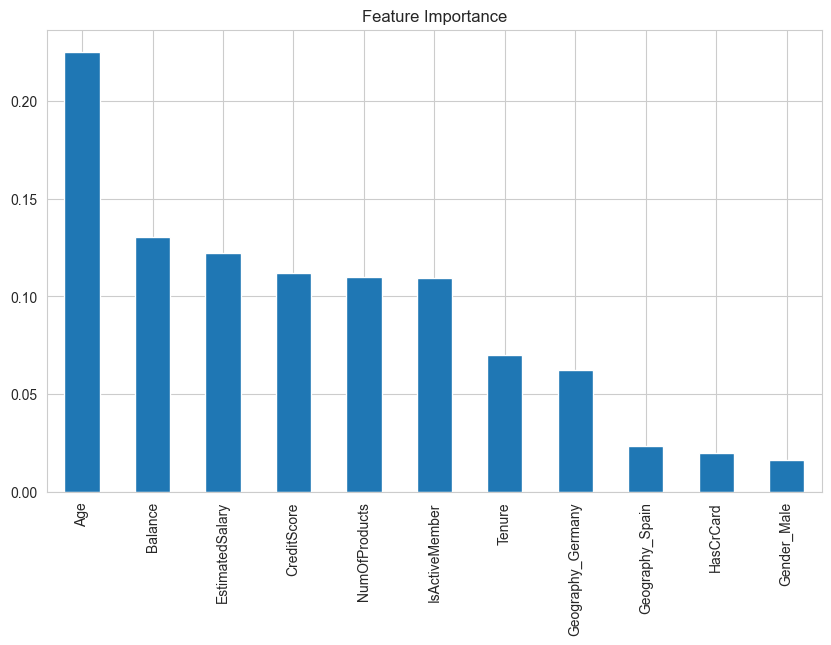

In [ ]:
#feature importance
import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,6))

plt.title("Feature Importance")
plt.show()

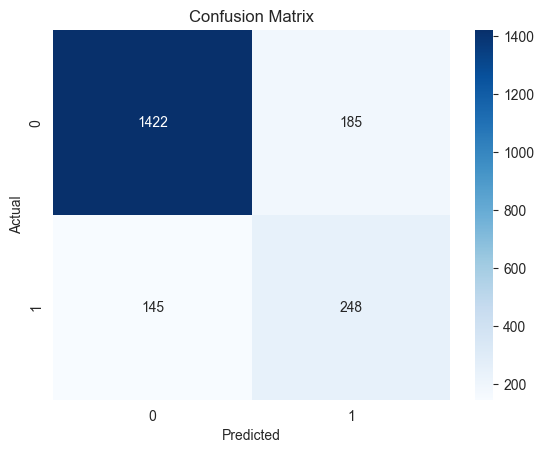

In [46]:
## confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

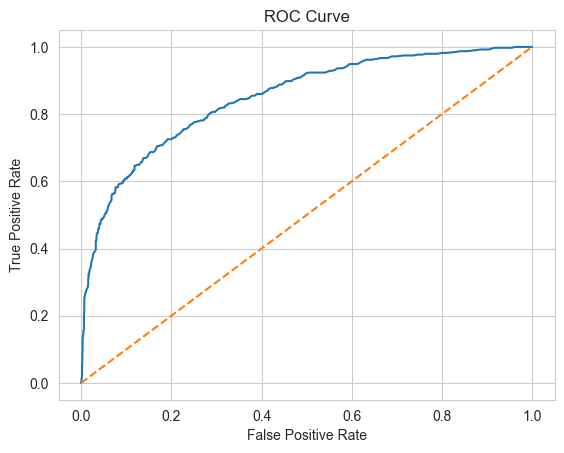

AUC Score: 0.8487287645811662


In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

C:\Users\chouh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


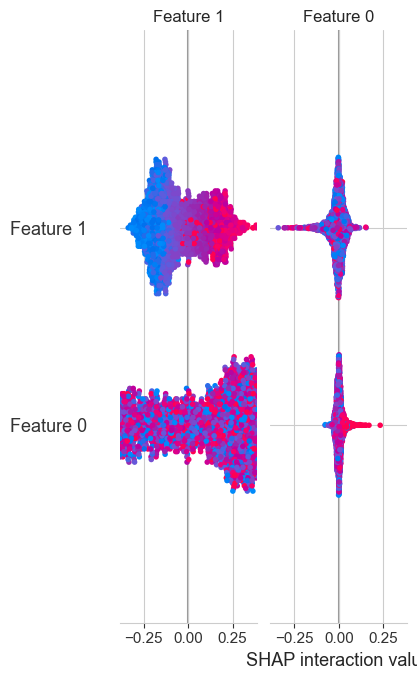

In [49]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [50]:
import pickle

pickle.dump(best_rf, open("../models/churn_model.pkl","wb"))